In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')


In [14]:

# Load dataset (adjust path if needed)
df = pd.read_csv(r"/Users/siddhu/Desktop/Programs/Machine Learning/Ex7/FlavorSense.csv")
df.head()


,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,NaN,Salty
1,NaN,Night Owl,Heavy,Temperate,Asian,Sweet
2,46.0,Night Owl,Heavy,Cold,Mixed,Sour
3,32.0,Early Bird,Heavy,Cold,Mediterranean,Salty
4,60.0,Night Owl,Moderate,Dry,Mediterranean,Sour


In [15]:
print(df.isnull().sum())

age                            968
sleep_cycle                    684
exercise_habits                804
climate_zone                   533
historical_cuisine_exposure    654
preferred_taste                  0
dtype: int64


In [16]:
df['age'].fillna(df['age'].median(), inplace=True)

categorical_cols = ['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [17]:
print(df.isnull().sum())

age                            0
sleep_cycle                    0
exercise_habits                0
climate_zone                   0
historical_cuisine_exposure    0
preferred_taste                0
dtype: int64


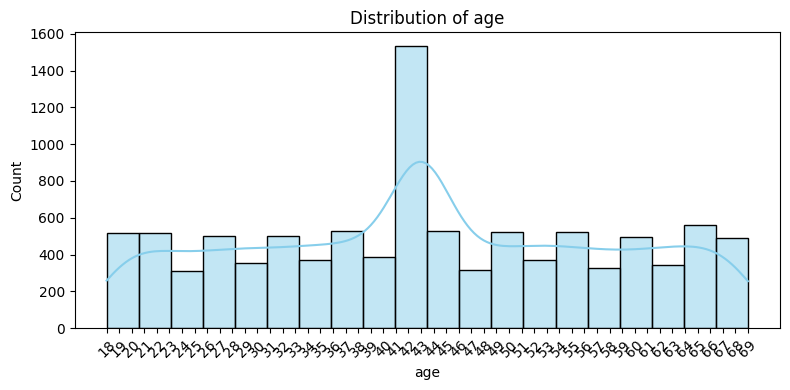

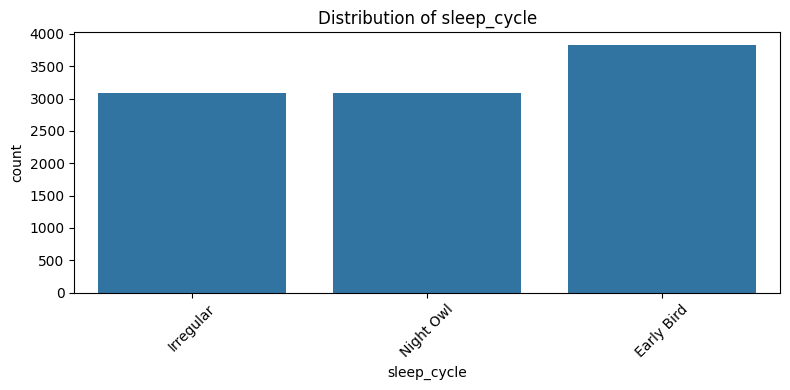

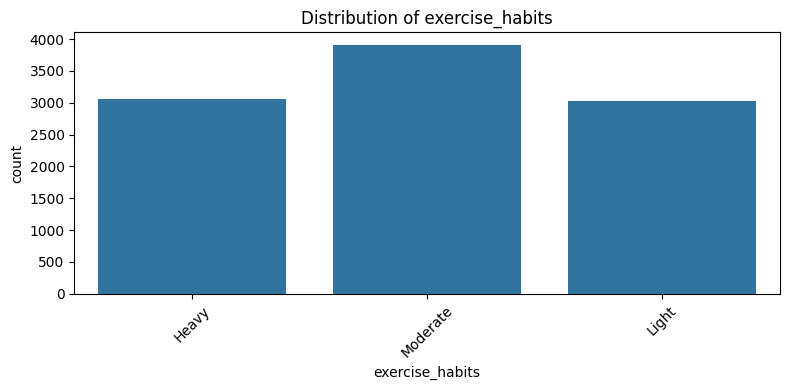

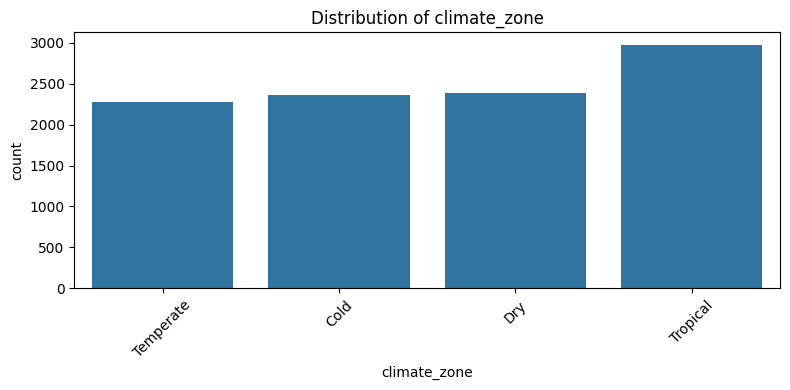

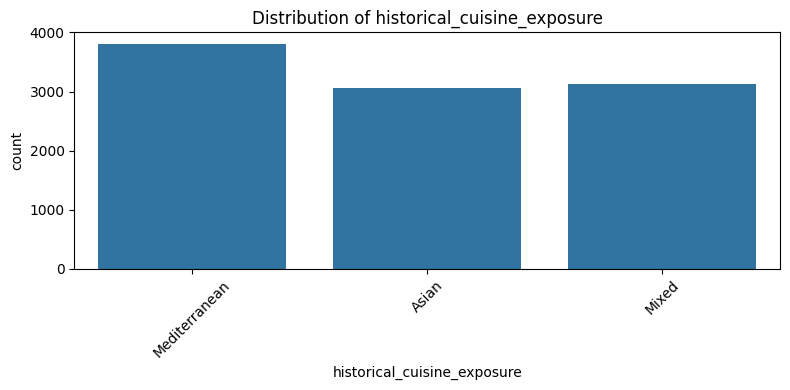

In [18]:

# Visualize feature distributions
for col in df.columns[:-1]:
    plt.figure(figsize=(8, 4))
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, kde=True, bins=20, color='skyblue')
        if np.issubdtype(df[col].dtype, np.number):
            plt.xticks(ticks=np.arange(int(df[col].min()), int(df[col].max())+1, step=1))
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [19]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [20]:

X = df.drop('preferred_taste', axis=1)
y = df['preferred_taste']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


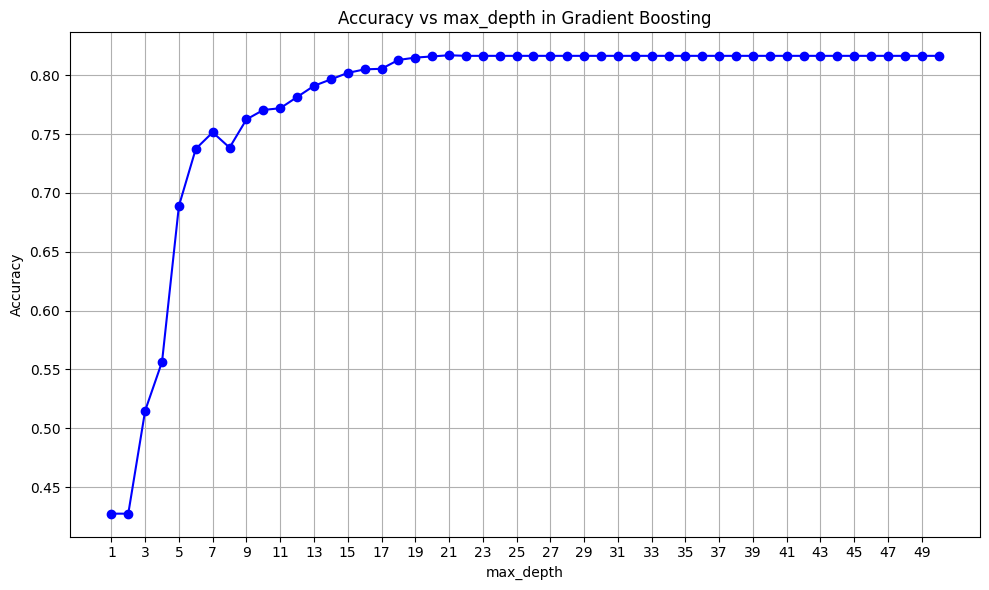

In [21]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Store accuracy for each depth
depths = range(1, 51)
accuracies = []

for depth in depths:
    model = GradientBoostingClassifier(
        n_estimators=2,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plotting the accuracy vs max_depth
plt.figure(figsize=(10, 6))
plt.plot(depths, accuracies, marker='o', linestyle='-', color='blue')
plt.title("Accuracy vs max_depth in Gradient Boosting")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(range(1, 51, 2))
plt.tight_layout()
plt.show()


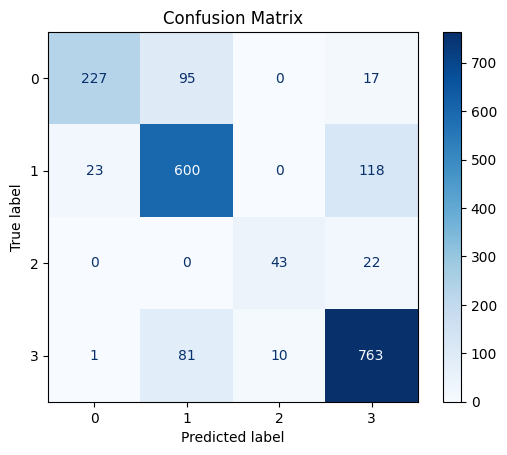

In [22]:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [23]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nXGBoost Classification Report:\n", classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8825

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       339
           1       0.84      0.88      0.86       741
           2       0.85      0.77      0.81        65
           3       0.92      0.88      0.90       855

    accuracy                           0.88      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.88      0.88      0.88      2000



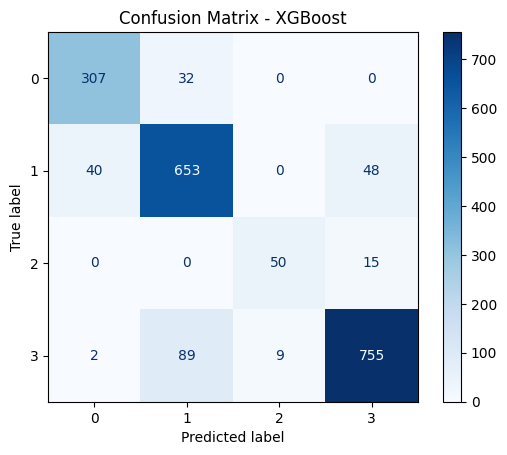

In [24]:
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()


AdaBoost Accuracy: 0.686

AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.95      0.74       339
           1       0.61      0.70      0.65       741
           2       0.89      0.12      0.22        65
           3       0.86      0.62      0.72       855

    accuracy                           0.69      2000
   macro avg       0.74      0.60      0.58      2000
weighted avg       0.72      0.69      0.68      2000



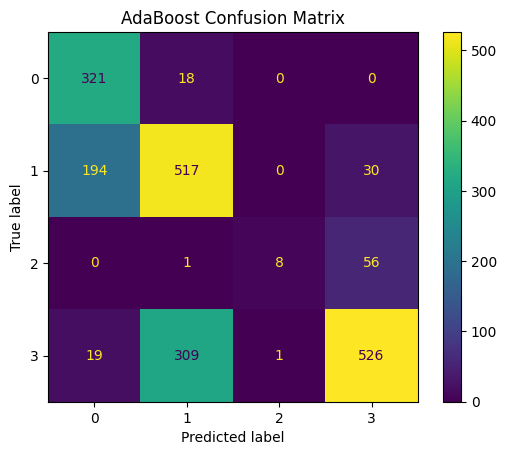

In [25]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=5, learning_rate=1.0, random_state=42)
ada_model.fit(X_train, y_train)

# Predict using AdaBoost
ada_pred = ada_model.predict(X_test)

# Evaluation
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("\nAdaBoost Classification Report:\n", classification_report(y_test, ada_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, ada_pred)).plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()